# 🫁 Chest X-Ray Diagnostic Assistant
## Notebook 01 — CNN : Principe, Construction & Classification

> **Objectif pédagogique** : Comprendre le CNN en profondeur AVANT tout code de production.  
> Ce notebook est structuré comme un **cours pratique interactif**, pas un simple pipeline.

---
```
PLAN DU NOTEBOOK
─────────────────────────────────────────────────────
PARTIE 1 │ Le principe du CNN — expliqué avant tout code
PARTIE 2 │ Chargement et exploration du dataset local
PARTIE 3 │ Construction pas à pas d'un CNN simple from scratch
PARTIE 4 │ Transfer Learning avec ResNet-18
PARTIE 5 │ Évaluation médicale (Recall, Confusion Matrix…)
─────────────────────────────────────────────────────
```

⚠️ **Règle absolue** : Chaque partie doit s'exécuter sans erreur avant d'avancer à la suivante.

In [1]:
# ── Imports globaux (exécute cette cellule EN PREMIER) ──────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import os
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Config matérielle
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ PyTorch {torch.__version__}')
print(f'✅ Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM disponible : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} Go')

# Chemin du dataset (déjà téléchargé)
DATA_ROOT = Path(r'D:\brave\PROJECT LINKEDIN\archive\chest_xray')
if not DATA_ROOT.exists():
    for cand in [Path('archive/chest_xray'), Path('../archive/chest_xray')]:
        if cand.exists():
            DATA_ROOT = cand.resolve()
            break
assert DATA_ROOT.exists(), f'❌ Dataset introuvable : {DATA_ROOT}'
print(f'\n✅ Dataset trouvé : {DATA_ROOT}')


✅ PyTorch 2.5.1+cu121
✅ Device : cuda
   GPU : NVIDIA GeForce GTX 1650 with Max-Q Design
   VRAM disponible : 4.3 Go

✅ Dataset trouvé : D:\brave\PROJECT LINKEDIN\archive\chest_xray


---
# 🧠 PARTIE 1 — Le principe du CNN, expliqué avant tout code

> *Avant d'écrire une seule ligne de PyTorch, on comprend ce qui se passe mathématiquement.*

## 1.1 — Qu'est-ce qu'une image pour un ordinateur ?

Une image numérique est **une matrice de nombres entiers** (entre 0 et 255).

| Type d'image | Dimensions | Description |
|---|---|---|
| Niveaux de gris | H × W × 1 | 1 valeur par pixel (0 = noir, 255 = blanc) |
| Couleur (RGB) | H × W × 3 | 3 valeurs par pixel (Rouge, Vert, Bleu) |
| Chest X-Ray | H × W × 1 | Radiographie = niveaux de gris |

**Le CNN ne "voit" pas une image comme toi.** Il reçoit un tableau de chiffres et apprend à y détecter des motifs.

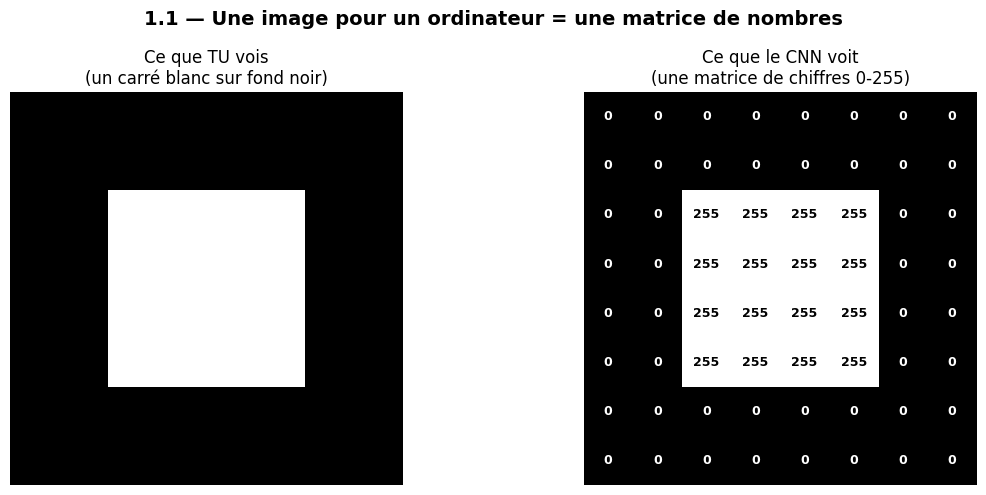

Shape de mini_image : (8, 8)  →  (Hauteur=8, Largeur=8)
Type des valeurs   : uint8  →  entiers de 0 à 255
Une image couleur aurait shape (8, 8, 3) pour les 3 canaux R-G-B


In [2]:
# ── 1.1 Visualisation : une image = une matrice de pixels ───────────────────
mini_image = np.array([
    [  0,   0,   0,   0,   0,   0,   0,   0],
    [  0,   0,   0,   0,   0,   0,   0,   0],
    [  0,   0, 255, 255, 255, 255,   0,   0],
    [  0,   0, 255, 255, 255, 255,   0,   0],
    [  0,   0, 255, 255, 255, 255,   0,   0],
    [  0,   0, 255, 255, 255, 255,   0,   0],
    [  0,   0,   0,   0,   0,   0,   0,   0],
    [  0,   0,   0,   0,   0,   0,   0,   0],
], dtype=np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('1.1 — Une image pour un ordinateur = une matrice de nombres', fontsize=14, fontweight='bold')

axes[0].imshow(mini_image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Ce que TU vois\n(un carré blanc sur fond noir)', fontsize=12)
axes[0].axis('off')

axes[1].imshow(mini_image, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Ce que le CNN voit\n(une matrice de chiffres 0-255)', fontsize=12)
for i in range(8):
    for j in range(8):
        color = 'black' if mini_image[i, j] > 127 else 'white'
        axes[1].text(j, i, str(mini_image[i, j]), ha='center', va='center',
                     fontsize=9, color=color, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'Shape de mini_image : {mini_image.shape}  →  (Hauteur=8, Largeur=8)')
print(f'Type des valeurs   : {mini_image.dtype}  →  entiers de 0 à 255')
print('Une image couleur aurait shape (8, 8, 3) pour les 3 canaux R-G-B')

---
## 1.2 — Le principe de la convolution : exemple MANUEL étape par étape

La **convolution** est l'opération centrale du CNN.  
Idée : on fait **glisser** un petit filtre (kernel) sur toute l'image.  
À chaque position, on calcule le **produit scalaire** entre le filtre et la région de l'image.

```
Résultat = Σ (valeur_pixel × valeur_filtre)  pour chaque position
```

On appelle ça une **"feature map"** (carte d'activation).

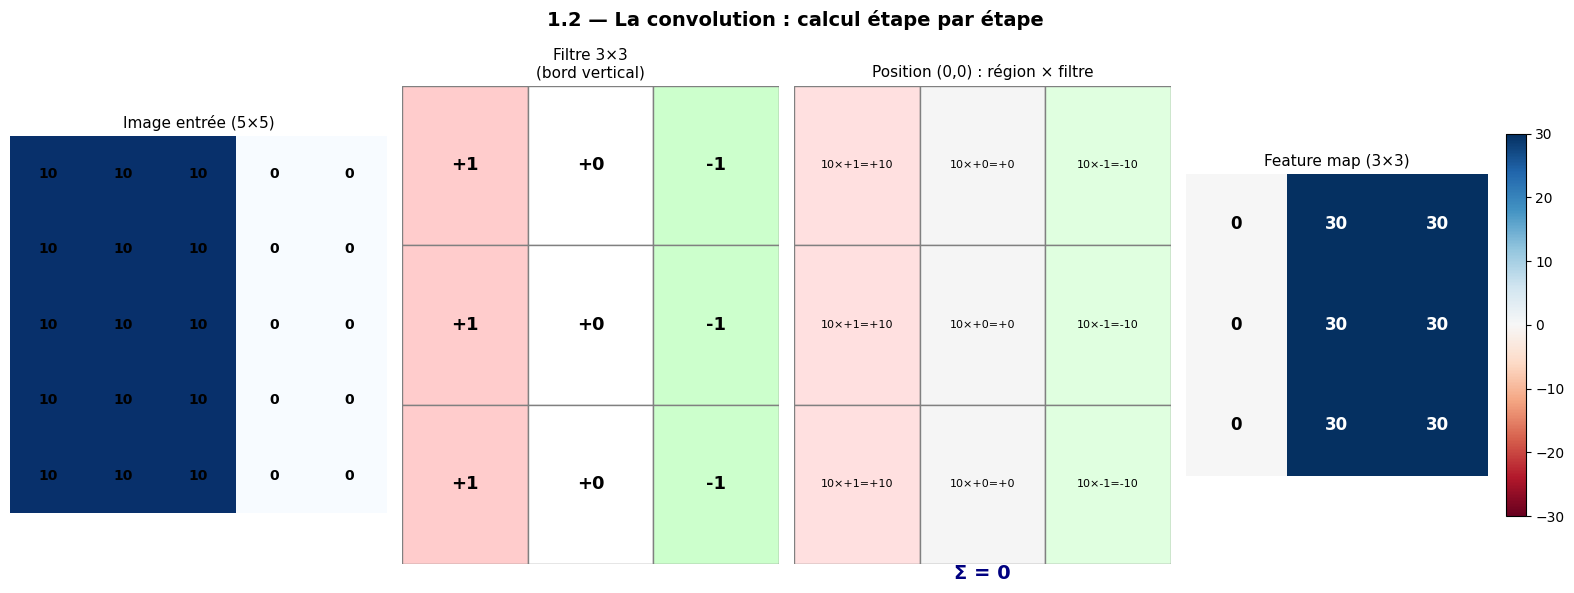

Calcul détaillé de la feature map :
  Position (0,0) → +0
  Position (0,1) → +30
  Position (0,2) → +30
  Position (1,0) → +0
  Position (1,1) → +30
  Position (1,2) → +30
  Position (2,0) → +0
  Position (2,1) → +30
  Position (2,2) → +30
Les valeurs ±30 indiquent le bord vertical détecté en colonne 2!


In [3]:
# ── 1.2 Convolution manuelle — calcul étape par étape ───────────────────────

image_5x5 = np.array([
    [10, 10, 10,  0,  0],
    [10, 10, 10,  0,  0],
    [10, 10, 10,  0,  0],
    [10, 10, 10,  0,  0],
    [10, 10, 10,  0,  0],
], dtype=np.float32)

# Filtre 3×3 : détecteur de bord VERTICAL
filtre_vertical = np.array([
    [ 1,  0, -1],
    [ 1,  0, -1],
    [ 1,  0, -1],
], dtype=np.float32)

def convolution_manuelle(image, filtre):
    H_img, W_img = image.shape
    H_f, W_f = filtre.shape
    H_out = H_img - H_f + 1
    W_out = W_img - W_f + 1
    feature_map = np.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            region = image[i:i+H_f, j:j+W_f]
            feature_map[i, j] = np.sum(region * filtre)
    return feature_map

feature_map = convolution_manuelle(image_5x5, filtre_vertical)

fig = plt.figure(figsize=(16, 6))
fig.suptitle('1.2 — La convolution : calcul étape par étape', fontsize=14, fontweight='bold')

ax1 = fig.add_subplot(1, 4, 1)
ax1.imshow(image_5x5, cmap='Blues', vmin=0, vmax=10)
ax1.set_title('Image entrée (5×5)', fontsize=11)
for i in range(5):
    for j in range(5):
        ax1.text(j, i, f'{int(image_5x5[i,j])}', ha='center', va='center', fontsize=10, fontweight='bold')
ax1.axis('off')

ax2 = fig.add_subplot(1, 4, 2)
ax2.set_xlim(-0.5, 2.5); ax2.set_ylim(-0.5, 2.5)
ax2.set_title('Filtre 3×3\n(bord vertical)', fontsize=11)
colors_f = [['#ffcccc','#ffffff','#ccffcc']]*3
for i in range(3):
    for j in range(3):
        ax2.add_patch(plt.Rectangle((j-0.5, (2-i)-0.5), 1, 1, color=colors_f[i][j], ec='gray'))
        ax2.text(j, 2-i, f'{int(filtre_vertical[i,j]):+d}', ha='center', va='center', fontsize=13, fontweight='bold')
ax2.axis('off')

ax3 = fig.add_subplot(1, 4, 3)
ax3.set_xlim(-0.5, 2.5); ax3.set_ylim(-0.5, 2.5)
ax3.set_title('Position (0,0) : région × filtre', fontsize=11)
region = image_5x5[0:3, 0:3]
total = 0
for i in range(3):
    for j in range(3):
        val = region[i,j] * filtre_vertical[i,j]
        total += val
        c = '#ffe0e0' if filtre_vertical[i,j] > 0 else ('#e0ffe0' if filtre_vertical[i,j] < 0 else '#f5f5f5')
        ax3.add_patch(plt.Rectangle((j-0.5, (2-i)-0.5), 1, 1, color=c, ec='gray'))
        ax3.text(j, 2-i, f'{int(region[i,j])}×{int(filtre_vertical[i,j]):+d}={int(val):+d}',
                 ha='center', va='center', fontsize=8)
ax3.text(1, -0.5, f'Σ = {int(total)}', ha='center', va='top', fontsize=14, fontweight='bold', color='navy')
ax3.axis('off')

ax4 = fig.add_subplot(1, 4, 4)
im = ax4.imshow(feature_map, cmap='RdBu', vmin=-30, vmax=30)
ax4.set_title('Feature map (3×3)', fontsize=11)
for i in range(3):
    for j in range(3):
        ax4.text(j, i, f'{int(feature_map[i,j])}', ha='center', va='center',
                 fontsize=12, fontweight='bold',
                 color='white' if abs(feature_map[i,j]) > 15 else 'black')
ax4.axis('off')
plt.colorbar(im, ax=ax4, shrink=0.8)

plt.tight_layout()
plt.show()

print('Calcul détaillé de la feature map :')
for i in range(3):
    for j in range(3):
        r = image_5x5[i:i+3, j:j+3]
        v = np.sum(r * filtre_vertical)
        print(f'  Position ({i},{j}) → {int(v):+d}')
print('Les valeurs ±30 indiquent le bord vertical détecté en colonne 2!')

---
## 1.3 — Les filtres détectent des motifs visuels

Un filtre CNN = un **détecteur de motif spécialisé**.  
Application de filtres classiques (Sobel, Laplacien) sur une vraie radio X-ray.

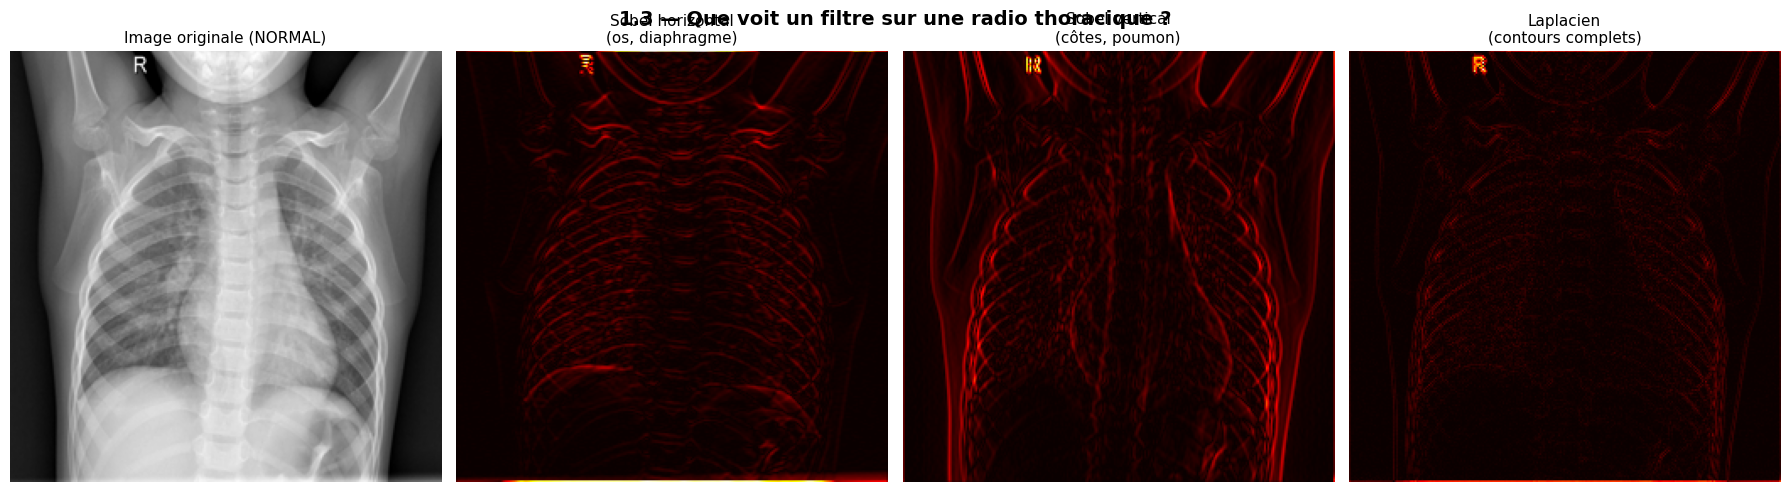

Conclusion :
  • Les filtres Sobel révèlent os, diaphragme, contours pulmonaires
  • Dans le CNN, ces filtres sont APPRIS automatiquement — pas fixés à la main!
  • Couches 1: bords | Couches profondes: textures complexes (opacités)


In [4]:
# ── 1.3 Filtres sur une vraie image du dataset ───────────────────────────────
def get_first_image(split, label):
    folder = DATA_ROOT / split / label
    imgs = list(folder.glob('*.jpeg')) + list(folder.glob('*.jpg')) + list(folder.glob('*.png'))
    return imgs[0] if imgs else None

img_path_normal = get_first_image('train', 'NORMAL')
img_array = np.array(Image.open(img_path_normal).convert('L').resize((256, 256)), dtype=np.float32)
img_norm = img_array / 255.0

sobel_h   = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float32)
sobel_v   = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float32)
laplacian = np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=np.float32)

def apply_filter(img_np, kernel_np):
    with torch.no_grad():
        t = torch.tensor(img_np).unsqueeze(0).unsqueeze(0)
        k = torch.tensor(kernel_np).unsqueeze(0).unsqueeze(0)
        out = F.conv2d(t, k, padding=1)
    return out.squeeze().numpy()

fm_h = apply_filter(img_norm, sobel_h)
fm_v = apply_filter(img_norm, sobel_v)
fm_l = apply_filter(img_norm, laplacian)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('1.3 — Que voit un filtre sur une radio thoracique ?', fontsize=14, fontweight='bold')
axes[0].imshow(img_norm, cmap='gray'); axes[0].set_title('Image originale (NORMAL)', fontsize=11); axes[0].axis('off')
axes[1].imshow(np.abs(fm_h), cmap='hot'); axes[1].set_title('Sobel horizontal\n(os, diaphragme)', fontsize=11); axes[1].axis('off')
axes[2].imshow(np.abs(fm_v), cmap='hot'); axes[2].set_title('Sobel vertical\n(côtes, poumon)', fontsize=11); axes[2].axis('off')
axes[3].imshow(np.abs(fm_l), cmap='hot'); axes[3].set_title('Laplacien\n(contours complets)', fontsize=11); axes[3].axis('off')
plt.tight_layout(); plt.show()

print('Conclusion :')
print('  • Les filtres Sobel révèlent os, diaphragme, contours pulmonaires')
print('  • Dans le CNN, ces filtres sont APPRIS automatiquement — pas fixés à la main!')
print('  • Couches 1: bords | Couches profondes: textures complexes (opacités)')

---
## 1.4 — Max Pooling : réduire la taille, garder l'essentiel

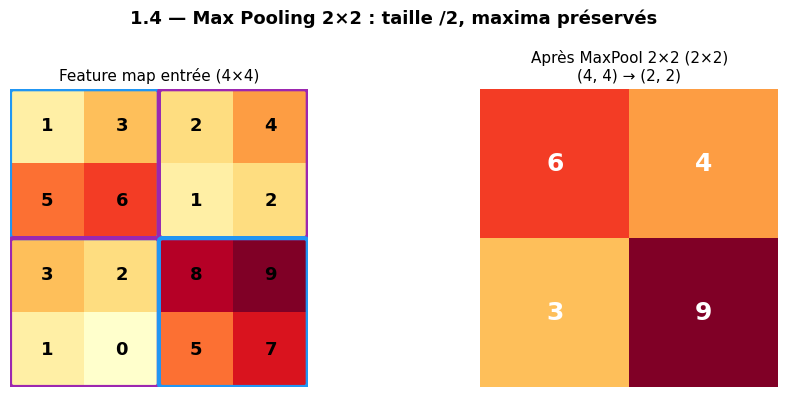

Bénéfices du Pooling :
  1. Taille réduite de 4 → calcul plus rapide
  2. Légère invariance à la translation (le motif peut bouger un peu)
  3. Les activations fortes (motifs détectés) sont préservées


In [5]:
# ── 1.4 Max Pooling manuel ───────────────────────────────────────────────────
fm_ex = np.array([[1,3,2,4],[5,6,1,2],[3,2,8,9],[1,0,5,7]], dtype=np.float32)

def max_pooling_2x2(fm):
    H, W = fm.shape
    out = np.zeros((H//2, W//2))
    for i in range(H//2):
        for j in range(W//2):
            out[i, j] = np.max(fm[i*2:(i+1)*2, j*2:(j+1)*2])
    return out

pooled = max_pooling_2x2(fm_ex)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('1.4 — Max Pooling 2×2 : taille /2, maxima préservés', fontsize=13, fontweight='bold')

axes[0].imshow(fm_ex, cmap='YlOrRd', vmin=0, vmax=9)
axes[0].set_title('Feature map entrée (4×4)', fontsize=11)
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, str(int(fm_ex[i,j])), ha='center', va='center', fontsize=13, fontweight='bold')
# Quadrillage des régions 2×2
for ri, rj in [(0,0),(0,2),(2,0),(2,2)]:
    color = '#2196F3' if (ri+rj) % 4 == 0 else '#9C27B0'
    axes[0].add_patch(mpatches.FancyBboxPatch((rj-0.45, ri-0.45), 1.9, 1.9,
        boxstyle='round,pad=0.05', linewidth=3, edgecolor=color, facecolor='none'))
axes[0].axis('off')

axes[1].imshow(pooled, cmap='YlOrRd', vmin=0, vmax=9)
axes[1].set_title(f'Après MaxPool 2×2 (2×2)\n{fm_ex.shape} → {pooled.shape}', fontsize=11)
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(int(pooled[i,j])), ha='center', va='center',
                     fontsize=18, fontweight='bold', color='white')
axes[1].axis('off')
plt.tight_layout(); plt.show()

print('Bénéfices du Pooling :')
print('  1. Taille réduite de 4 → calcul plus rapide')
print('  2. Légère invariance à la translation (le motif peut bouger un peu)')
print('  3. Les activations fortes (motifs détectés) sont préservées')

---
## 1.5 — Architecture CNN : des bords aux structures complexes

| Profondeur | Ce que la couche détecte |
|---|---|
| Couche 1 | Bords, gradients de luminosité |
| Couche 2 | Coins, textures, jonctions |
| Couche 3 | Formes simples (arcs, ellipses…) |
| **Couches profondes** | **Structures complexes : opacités, infiltrats, consolidations** |

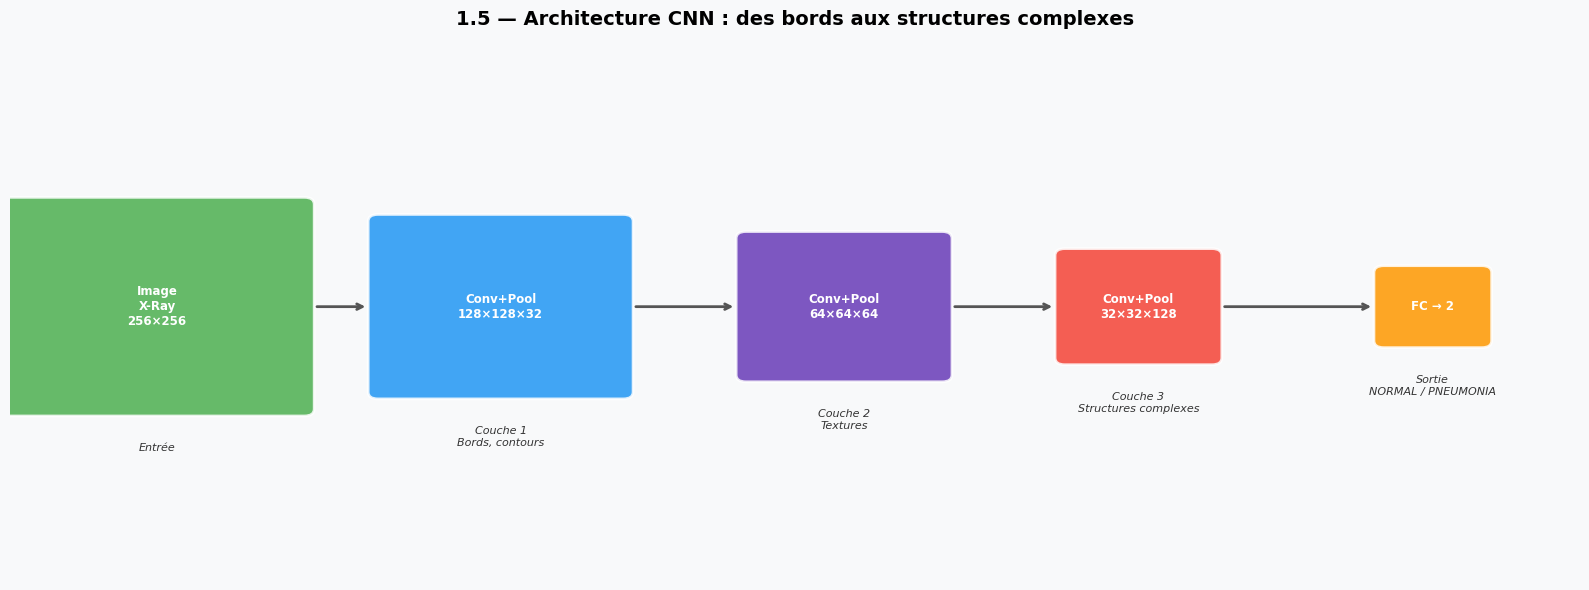

In [6]:
# ── 1.5 Schéma CNN pédagogique ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#f8f9fa')
ax.set_xlim(0, 16); ax.set_ylim(0, 8); ax.axis('off')
ax.set_title('1.5 — Architecture CNN : des bords aux structures complexes',
             fontsize=14, fontweight='bold')

blocks = [
    (1.5, 3, '#4CAF50', 'Image\nX-Ray\n256×256', 'Entrée'),
    (5,   2.5, '#2196F3', 'Conv+Pool\n128×128×32', 'Couche 1\nBords, contours'),
    (8.5, 2, '#673AB7', 'Conv+Pool\n64×64×64', 'Couche 2\nTextures'),
    (11.5,1.5, '#F44336', 'Conv+Pool\n32×32×128', 'Couche 3\nStructures complexes'),
    (14.5,1, '#FF9800', 'FC → 2', 'Sortie\nNORMAL / PNEUMONIA'),
]

prev_x = None
for (x, h, color, label, title) in blocks:
    y = 4 - h/2
    rect = mpatches.FancyBboxPatch((x - h/2, y), h, h,
                                    boxstyle='round,pad=0.1',
                                    facecolor=color, alpha=0.85, edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text(x, 4, label, ha='center', va='center', fontsize=8.5, color='white', fontweight='bold')
    ax.text(x, y - 0.5, title, ha='center', va='top', fontsize=8, color='#333', style='italic')
    if prev_x is not None:
        ax.annotate('', xy=(x - h/2 - 0.1, 4), xytext=(prev_x + prev_h/2 + 0.1, 4),
                    arrowprops=dict(arrowstyle='->', color='#555', lw=2))
    prev_x, prev_h = x, h

plt.tight_layout(); plt.show()

---
## 1.6 — La couche Fully Connected et la décision finale

Après les couches de convolution :
1. **Flatten** : aplatir la feature map en vecteur 1D
2. **FC layers** : couches denses (comme dans un MLP classique)
3. **Softmax** : convertit les logits en probabilités

$$P(\text{PNEUMONIA}) = \frac{e^{z_{\text{pneu}}}}{e^{z_{\text{normal}}} + e^{z_{\text{pneu}}}}$$

C'est **exactement** une Régression Logistique sur les features extraites par le CNN !

---
# 📁 PARTIE 2 — Chargement et exploration du dataset

> Dataset **déjà présent localement** — aucun téléchargement.

In [7]:
# ── 2.1 Structure des dossiers ───────────────────────────────────────────────
print('Structure du dataset :')
print('─' * 50)
stats = {}
for split in ['train', 'val', 'test']:
    stats[split] = {}
    for label in ['NORMAL', 'PNEUMONIA']:
        p = DATA_ROOT / split / label
        imgs = list(p.glob('*.jpeg')) + list(p.glob('*.jpg')) + list(p.glob('*.png')) if p.exists() else []
        stats[split][label] = len(imgs)
        print(f'  {split}/{label:<12} → {len(imgs):>5} images')

print('─' * 50)
for split in ['train', 'val', 'test']:
    n = stats[split].get('NORMAL', 0)
    p = stats[split].get('PNEUMONIA', 0)
    print(f'{split:>5}: {n+p:>5} images | NORMAL:{n:>5} | PNEUMONIA:{p:>5} | ratio={p/n:.1f}x' if n else f'{split}: données manquantes')

Structure du dataset :
──────────────────────────────────────────────────
  train/NORMAL       →  1341 images
  train/PNEUMONIA    →  3875 images
  val/NORMAL       →     8 images
  val/PNEUMONIA    →     8 images
  test/NORMAL       →   234 images
  test/PNEUMONIA    →   390 images
──────────────────────────────────────────────────
train:  5216 images | NORMAL: 1341 | PNEUMONIA: 3875 | ratio=2.9x
  val:    16 images | NORMAL:    8 | PNEUMONIA:    8 | ratio=1.0x
 test:   624 images | NORMAL:  234 | PNEUMONIA:  390 | ratio=1.7x


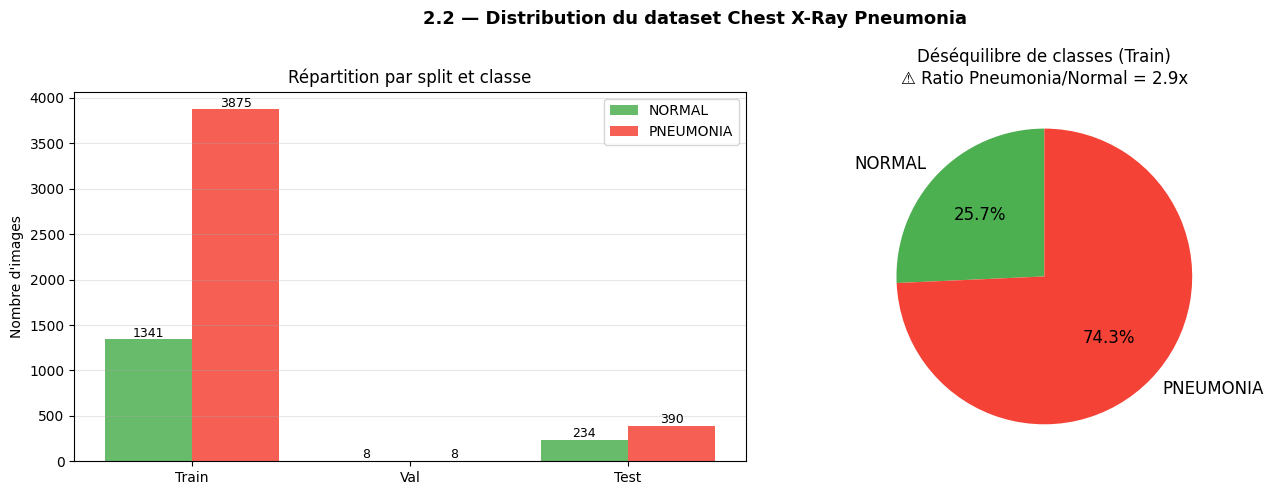

⚠️ Déséquilibre → nécessite class_weight dans la loss (traité en Partie 4)


In [8]:
# ── 2.2 Distribution des classes ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('2.2 — Distribution du dataset Chest X-Ray Pneumonia', fontsize=13, fontweight='bold')

splits_l = ['train', 'val', 'test']
x = np.arange(len(splits_l))
normals   = [stats[s].get('NORMAL', 0) for s in splits_l]
pneumonia = [stats[s].get('PNEUMONIA', 0) for s in splits_l]

b1 = axes[0].bar(x-0.2, normals, 0.4, label='NORMAL', color='#4CAF50', alpha=0.85)
b2 = axes[0].bar(x+0.2, pneumonia, 0.4, label='PNEUMONIA', color='#F44336', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(['Train','Val','Test'])
axes[0].set_ylabel("Nombre d'images"); axes[0].set_title('Répartition par split et classe')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
for bar in list(b1)+list(b2):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 str(int(bar.get_height())), ha='center', fontsize=9)

n_tr = stats['train'].get('NORMAL',0)
p_tr = stats['train'].get('PNEUMONIA',0)
axes[1].pie([n_tr, p_tr], labels=['NORMAL','PNEUMONIA'], colors=['#4CAF50','#F44336'],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize':12})
axes[1].set_title(f'Déséquilibre de classes (Train)\n⚠️ Ratio Pneumonia/Normal = {p_tr/n_tr:.1f}x')

plt.tight_layout(); plt.show()
print('⚠️ Déséquilibre → nécessite class_weight dans la loss (traité en Partie 4)')

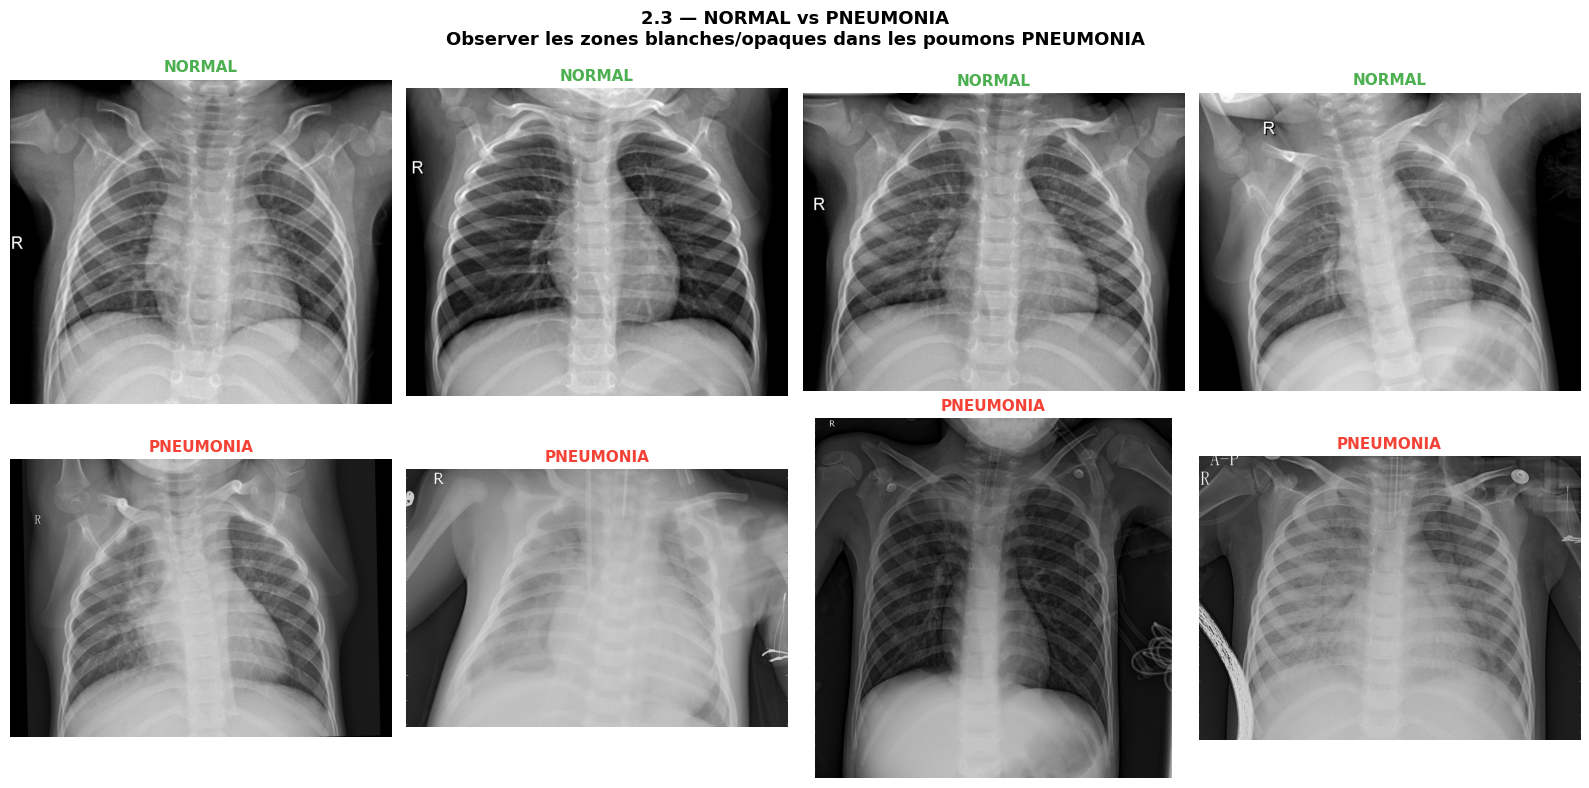

NORMAL    → poumons clairs, structure bien définie
PNEUMONIA → zones blanches/floues (consolidation, infiltrats, fluide)
Le CNN apprendra à détecter ces patterns automatiquement!


In [9]:
# ── 2.3 NORMAL vs PNEUMONIA — observation visuelle ───────────────────────────
def get_images(split, label, n=4):
    folder = DATA_ROOT / split / label
    imgs = list(folder.glob('*.jpeg')) + list(folder.glob('*.jpg')) + list(folder.glob('*.png'))
    np.random.shuffle(imgs)
    return imgs[:n]

np.random.seed(42)
normal_imgs    = get_images('train', 'NORMAL', 4)
pneumonia_imgs = get_images('train', 'PNEUMONIA', 4)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('2.3 — NORMAL vs PNEUMONIA\nObserver les zones blanches/opaques dans les poumons PNEUMONIA',
             fontsize=13, fontweight='bold')

for j, p in enumerate(normal_imgs):
    axes[0,j].imshow(Image.open(p).convert('L'), cmap='gray')
    axes[0,j].set_title('NORMAL', fontsize=11, color='#4CAF50', fontweight='bold')
    axes[0,j].axis('off')

for j, p in enumerate(pneumonia_imgs):
    axes[1,j].imshow(Image.open(p).convert('L'), cmap='gray')
    axes[1,j].set_title('PNEUMONIA', fontsize=11, color='#F44336', fontweight='bold')
    axes[1,j].axis('off')

plt.tight_layout(); plt.show()

print('NORMAL    → poumons clairs, structure bien définie')
print('PNEUMONIA → zones blanches/floues (consolidation, infiltrats, fluide)')
print('Le CNN apprendra à détecter ces patterns automatiquement!')

---
# 🔨 PARTIE 3 — CNN simple from scratch

> Voir chaque composant de la Partie 1 dans le code réel.

In [10]:
# ── 3.1 Architecture TinyCNN ─────────────────────────────────────────────────
class TinyCNN(nn.Module):
    """
    Petit CNN pédagogique — 3 couches Conv + MaxPool.
    Entrée : [B, 1, 128, 128]  (niveaux de gris)
    Sortie : [B, 2]            (NORMAL ou PNEUMONIA)
    """
    def __init__(self):
        super().__init__()
        # Bloc 1 : [1,128,128] → [16,64,64]
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        # Bloc 2 : [16,64,64] → [32,32,32]
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        # Bloc 3 : [32,32,32] → [64,16,16]
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        # FC : 64×16×16=16384 → 128 → 2
        self.fc1 = nn.Linear(64*16*16, 128)
        self.fc2 = nn.Linear(128, 2)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))  # [B,1,128,128] → [B,16,64,64]
        x = self.pool2(F.relu(self.conv2(x)))  # [B,16,64,64]  → [B,32,32,32]
        x = self.pool3(F.relu(self.conv3(x)))  # [B,32,32,32]  → [B,64,16,16]
        x = x.view(x.size(0), -1)              # Flatten → [B,16384]
        x = self.dropout(F.relu(self.fc1(x)))  # [B,16384] → [B,128]
        return self.fc2(x)                      # [B,128] → [B,2]

tiny_model = TinyCNN()
print(tiny_model)
print(f'\nParamètres totaux : {sum(p.numel() for p in tiny_model.parameters()):,}')

TinyCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

Paramètres totaux : 2,120,834


In [11]:
# ── 3.2 Suivi des shapes à travers le réseau ────────────────────────────────
print('Shapes à travers TinyCNN (trace forward pass)')
print('─' * 65)
x = torch.randn(1, 1, 128, 128)
print(f'Entrée                        : {tuple(x.shape)}')
x = F.relu(tiny_model.conv1(x))
print(f'Après Conv1 (16 filtres 3×3)  : {tuple(x.shape)} → 16 feature maps 128×128')
x = tiny_model.pool1(x)
print(f'Après MaxPool1 (2×2)          : {tuple(x.shape)} → taille /2 = 64×64')
x = F.relu(tiny_model.conv2(x))
print(f'Après Conv2 (32 filtres 3×3)  : {tuple(x.shape)} → 32 feature maps 64×64')
x = tiny_model.pool2(x)
print(f'Après MaxPool2 (2×2)          : {tuple(x.shape)} → taille /2 = 32×32')
x = F.relu(tiny_model.conv3(x))
print(f'Après Conv3 (64 filtres 3×3)  : {tuple(x.shape)} → 64 feature maps 32×32')
x = tiny_model.pool3(x)
print(f'Après MaxPool3 (2×2)          : {tuple(x.shape)} → taille /2 = 16×16')
x = x.view(x.size(0), -1)
print(f'Après Flatten                 : {tuple(x.shape)} → 64×16×16 = 16384')
x = F.relu(tiny_model.fc1(x))
print(f'Après FC1 (128 neurones)      : {tuple(x.shape)}')
x = tiny_model.fc2(x)
print(f'Après FC2 (2 classes)         : {tuple(x.shape)} → [logit_NORMAL, logit_PNEUMONIA]')
print('─' * 65)
print('✅ Forward pass complet — aucune erreur de dimension!')

Shapes à travers TinyCNN (trace forward pass)
─────────────────────────────────────────────────────────────────
Entrée                        : (1, 1, 128, 128)
Après Conv1 (16 filtres 3×3)  : (1, 16, 128, 128) → 16 feature maps 128×128
Après MaxPool1 (2×2)          : (1, 16, 64, 64) → taille /2 = 64×64
Après Conv2 (32 filtres 3×3)  : (1, 32, 64, 64) → 32 feature maps 64×64
Après MaxPool2 (2×2)          : (1, 32, 32, 32) → taille /2 = 32×32
Après Conv3 (64 filtres 3×3)  : (1, 64, 32, 32) → 64 feature maps 32×32
Après MaxPool3 (2×2)          : (1, 64, 16, 16) → taille /2 = 16×16
Après Flatten                 : (1, 16384) → 64×16×16 = 16384
Après FC1 (128 neurones)      : (1, 128)
Après FC2 (2 classes)         : (1, 2) → [logit_NORMAL, logit_PNEUMONIA]
─────────────────────────────────────────────────────────────────
✅ Forward pass complet — aucune erreur de dimension!


In [12]:
# ── 3.3 DataLoaders (sous-ensemble réduit pour démo) ────────────────────────
IMG_SIZE_TINY = 128
BATCH_SIZE_TINY = 32
SUBSET_SIZE = 500  # 250 NORMAL + 250 PNEUMONIA

transform_tiny = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE_TINY, IMG_SIZE_TINY)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

train_ds_full = datasets.ImageFolder(root=str(DATA_ROOT/'train'), transform=transform_tiny)
test_ds_tiny  = datasets.ImageFolder(root=str(DATA_ROOT/'test'),  transform=transform_tiny)

# Sous-ensemble équilibré
lbl2idx = {0:[], 1:[]}
for idx, (_, lbl) in enumerate(train_ds_full.samples):
    lbl2idx[lbl].append(idx)
subset_idx = lbl2idx[0][:SUBSET_SIZE//2] + lbl2idx[1][:SUBSET_SIZE//2]
np.random.shuffle(subset_idx)

train_loader_tiny = DataLoader(Subset(train_ds_full, subset_idx), batch_size=BATCH_SIZE_TINY, shuffle=True,  num_workers=0)
test_loader_tiny  = DataLoader(test_ds_tiny, batch_size=BATCH_SIZE_TINY, shuffle=False, num_workers=0)

print(f'Classes : {train_ds_full.classes}  (index: {train_ds_full.class_to_idx})')
print(f'Sous-ensemble train : {len(subset_idx)} images ({SUBSET_SIZE//2} par classe)')
print(f'Test complet        : {len(test_ds_tiny)} images')

Classes : ['NORMAL', 'PNEUMONIA']  (index: {'NORMAL': 0, 'PNEUMONIA': 1})
Sous-ensemble train : 500 images (250 par classe)
Test complet        : 624 images


In [13]:
# ── 3.4 Entraînement TinyCNN ─────────────────────────────────────────────────
EPOCHS_TINY = 8

tiny_model = TinyCNN().to(DEVICE)
criterion_tiny = nn.CrossEntropyLoss()
optimizer_tiny = optim.Adam(tiny_model.parameters(), lr=1e-3)

def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    training = optimizer is not None
    model.train() if training else model.eval()
    tot_loss, correct, total = 0, 0, 0
    ctx = torch.no_grad() if not training else torch.enable_grad()
    with ctx:
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            if training: optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, lbls)
            if training: loss.backward(); optimizer.step()
            tot_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == lbls).sum().item()
            total += imgs.size(0)
    return tot_loss/total, correct/total

hist_tiny = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
print(f'Entraînement TinyCNN — {EPOCHS_TINY} epochs, {len(subset_idx)} images')
print('─' * 65)
for ep in range(1, EPOCHS_TINY+1):
    tl, ta = run_epoch(tiny_model, train_loader_tiny, criterion_tiny, optimizer_tiny)
    vl, va = run_epoch(tiny_model, test_loader_tiny,  criterion_tiny)
    hist_tiny['train_loss'].append(tl); hist_tiny['train_acc'].append(ta)
    hist_tiny['val_loss'].append(vl);   hist_tiny['val_acc'].append(va)
    print(f'Epoch [{ep:2d}/{EPOCHS_TINY}] | Train Loss:{tl:.4f} Acc:{ta:.3f} | Val Loss:{vl:.4f} Acc:{va:.3f}')
print('─' * 65)
print(f'Accuracy finale : {hist_tiny["val_acc"][-1]:.1%}')
print('Note: performance limitée (mini-dataset, 3 couches). La Partie 4 va drastiquement améliorer.')

Entraînement TinyCNN — 8 epochs, 500 images
─────────────────────────────────────────────────────────────────
Epoch [ 1/8] | Train Loss:0.6401 Acc:0.662 | Val Loss:0.4991 Acc:0.848
Epoch [ 2/8] | Train Loss:0.2789 Acc:0.898 | Val Loss:0.4422 Acc:0.796
Epoch [ 3/8] | Train Loss:0.1735 Acc:0.934 | Val Loss:0.6527 Acc:0.763
Epoch [ 4/8] | Train Loss:0.1041 Acc:0.970 | Val Loss:0.6419 Acc:0.768
Epoch [ 5/8] | Train Loss:0.0814 Acc:0.982 | Val Loss:0.7040 Acc:0.796
Epoch [ 6/8] | Train Loss:0.0686 Acc:0.974 | Val Loss:0.9182 Acc:0.761
Epoch [ 7/8] | Train Loss:0.0656 Acc:0.974 | Val Loss:0.4860 Acc:0.827
Epoch [ 8/8] | Train Loss:0.1160 Acc:0.942 | Val Loss:1.2118 Acc:0.688
─────────────────────────────────────────────────────────────────
Accuracy finale : 68.8%
Note: performance limitée (mini-dataset, 3 couches). La Partie 4 va drastiquement améliorer.


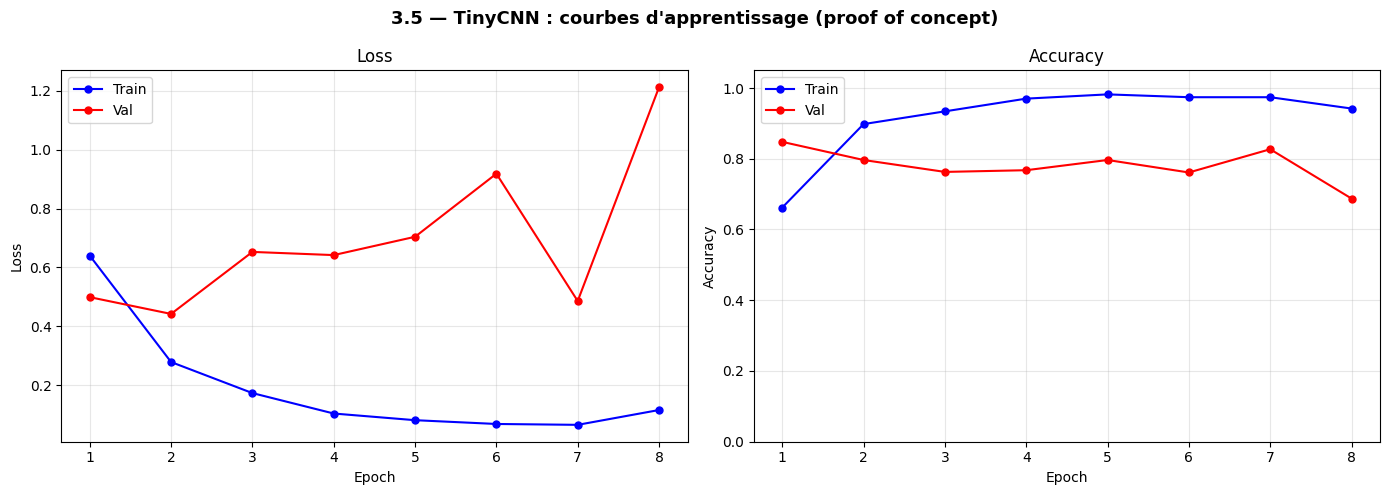

In [14]:
# ── 3.5 Courbes d'apprentissage TinyCNN ──────────────────────────────────────
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle("3.5 — TinyCNN : courbes d'apprentissage (proof of concept)", fontsize=13, fontweight='bold')
ep_r = range(1, EPOCHS_TINY+1)
a1.plot(ep_r, hist_tiny['train_loss'], 'b-o', label='Train', ms=5)
a1.plot(ep_r, hist_tiny['val_loss'],   'r-o', label='Val',   ms=5)
a1.set_xlabel('Epoch'); a1.set_ylabel('Loss'); a1.set_title('Loss'); a1.legend(); a1.grid(alpha=0.3)
a2.plot(ep_r, hist_tiny['train_acc'], 'b-o', label='Train', ms=5)
a2.plot(ep_r, hist_tiny['val_acc'],   'r-o', label='Val',   ms=5)
a2.set_xlabel('Epoch'); a2.set_ylabel('Accuracy'); a2.set_title('Accuracy')
a2.set_ylim(0, 1.05); a2.legend(); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
# 🚀 PARTIE 4 — Transfer Learning avec ResNet-18

## Pourquoi passer à un modèle pré-entraîné ?

| | TinyCNN (from scratch) | ResNet-18 (Transfer Learning) |
|---|---|---|
| Paramètres | ~2M | 11M |
| Features | Basiques | Très riches (ImageNet) |
| Données nécessaires | Millions | Quelques milliers |
| Performance | ~75-80% | **>95%** |

**Principe** : ResNet-18 a appris sur 1.2M images (ImageNet).  
→ On **gèle** le backbone (features universelles déjà apprises)  
→ On **remplace uniquement la dernière couche** : 1000 classes → 2 classes

In [15]:
# ── 4.1 DataLoaders complets pour ResNet-18 ──────────────────────────────────
IMG_SIZE = 224      # ResNet attend ≥ 224×224
BATCH_SIZE = 16     # Adapté GPU 4 Go VRAM

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

tfm_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
tfm_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = datasets.ImageFolder(str(DATA_ROOT / 'train'), tfm_train)
val_ds   = datasets.ImageFolder(str(DATA_ROOT / 'val'),   tfm_eval)
test_ds  = datasets.ImageFolder(str(DATA_ROOT / 'test'),  tfm_eval)

# num_workers=0 recommandé sous Windows dans Jupyter pour éviter les freezes
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train : {len(train_ds)} images | Val : {len(val_ds)} | Test : {len(test_ds)}')
print(f'Batch size : {BATCH_SIZE} | Image size : {IMG_SIZE}×{IMG_SIZE}')


Train : 5216 images | Val : 16 | Test : 624
Batch size : 16 | Image size : 224×224


In [16]:
# ── 4.2 class_weight pour le déséquilibre ────────────────────────────────────
class_counts = np.bincount([lbl for _, lbl in train_ds.samples])
n_cls = len(class_counts)
class_weights = torch.tensor(
    [len(train_ds) / (n_cls * c) for c in class_counts], dtype=torch.float32
).to(DEVICE)

for i, (name, cnt) in enumerate(zip(train_ds.classes, class_counts)):
    print(f'Classe {i} ({name:>10}) : {cnt:>5} imgs → poids = {class_weights[i]:.3f}')
print('\n→ Poids plus élevé sur NORMAL (minoritaire) = pénalisation plus forte des erreurs')
print('→ Contexte médical : FN (PNEUMONIA manquée) est plus dangereux qu\'un FP!')

Classe 0 (    NORMAL) :  1341 imgs → poids = 1.945
Classe 1 ( PNEUMONIA) :  3875 imgs → poids = 0.673

→ Poids plus élevé sur NORMAL (minoritaire) = pénalisation plus forte des erreurs
→ Contexte médical : FN (PNEUMONIA manquée) est plus dangereux qu'un FP!


In [17]:
# ── 4.3 Chargement et adaptation ResNet-18 ───────────────────────────────────
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Remplacer la couche finale : 1000 classes → 2 classes
in_feat = model.fc.in_features  # 512
model.fc = nn.Linear(in_feat, 2)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# LR différentiel : backbone lr faible, tête lr plus élevé
optimizer = optim.Adam([
    {'params': [p for n, p in model.named_parameters() if 'fc' not in n], 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-3},
])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.3)

print(f'ResNet-18 adapté : dernière couche {in_feat} → 2')
print(f'Paramètres totaux : {sum(p.numel() for p in model.parameters()):,}')


ResNet-18 adapté : dernière couche 512 → 2
Paramètres totaux : 11,177,538


In [ ]:
# ── 4.4 Entraînement ResNet-18 ───────────────────────────────────────────────
EPOCHS = 10
USE_AMP = (DEVICE.type == 'cuda')
scaler = torch.amp.GradScaler('cuda') if USE_AMP else None

# Chemin universel vers le fichier de sauvegarde best_resnet18.pt
SAVE_PATH = Path('notebooks/best_resnet18.pt')
if not SAVE_PATH.parent.exists():
    SAVE_PATH = Path('best_resnet18.pt')
SAVE_PATH = SAVE_PATH.resolve()

def train_ep(model, loader, criterion, optimizer, scaler=None):
    model.train()
    tot_loss, correct, total = 0.0, 0, 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        if scaler:
            with torch.amp.autocast('cuda'):
                out = model(imgs)
                loss = criterion(out, lbls)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            out = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
        tot_loss += loss.item() * imgs.size(0)
        correct  += (out.argmax(1) == lbls).sum().item()
        total    += imgs.size(0)
    return tot_loss / total, correct / total

def eval_ep(model, loader, criterion):
    model.eval()
    tot_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            out = model(imgs)
            loss = criterion(out, lbls)
            tot_loss += loss.item() * imgs.size(0)
            correct  += (out.argmax(1) == lbls).sum().item()
            total    += imgs.size(0)
    return tot_loss / total, correct / total

hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')

print(f'Entraînement ResNet-18 — {EPOCHS} epochs | AMP={USE_AMP} | DEVICE={DEVICE}')
print('─' * 75)
for ep in range(1, EPOCHS + 1):
    tl, ta = train_ep(model, train_loader, criterion, optimizer, scaler)
    vl, va = eval_ep(model, val_loader, criterion)
    scheduler.step(vl)
    hist['train_loss'].append(tl)
    hist['train_acc'].append(ta)
    hist['val_loss'].append(vl)
    hist['val_acc'].append(va)
    mark = '  ✅ best' if vl < best_val_loss else ''
    if vl < best_val_loss:
        best_val_loss = vl
        torch.save(model.state_dict(), SAVE_PATH)
    print(f'Epoch [{ep:2d}/{EPOCHS}] | Train Loss:{tl:.4f} Acc:{ta:.3f} | Val Loss:{vl:.4f} Acc:{va:.3f}{mark}')
print('─' * 75)
print(f'✅ Meilleur modèle sauvegardé : {SAVE_PATH} (val_loss: {best_val_loss:.4f})')


Entraînement ResNet-18 — 10 epochs | AMP=True | DEVICE=cuda
───────────────────────────────────────────────────────────────────────────
Epoch [ 1/10] | Train Loss:0.1472 Acc:0.945 | Val Loss:0.1234 Acc:1.000  ✅ best
Epoch [ 2/10] | Train Loss:0.0861 Acc:0.968 | Val Loss:0.9115 Acc:0.688
Epoch [ 3/10] | Train Loss:0.0608 Acc:0.976 | Val Loss:0.0325 Acc:1.000  ✅ best
Epoch [ 4/10] | Train Loss:0.0654 Acc:0.976 | Val Loss:0.0836 Acc:1.000
Epoch [ 5/10] | Train Loss:0.0566 Acc:0.980 | Val Loss:0.0640 Acc:1.000


KeyboardInterrupt: 

## 4.5 — Visualisation des courbes d'apprentissage de ResNet-18


In [ ]:
# ── 4.5 Courbes ResNet-18 ────────────────────────────────────────────────────
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("4.5 — ResNet-18 Transfer Learning : courbes d'apprentissage", fontsize=13, fontweight='bold')
ep_r = range(1, len(hist['train_loss']) + 1)
a1.plot(ep_r, hist['train_loss'], 'b-o', label='Train', ms=5)
a1.plot(ep_r, hist['val_loss'],   'r-o', label='Val',   ms=5)
a1.set_xlabel('Epoch'); a1.set_ylabel('Loss'); a1.set_title('Loss'); a1.legend(); a1.grid(alpha=0.3)
a2.plot(ep_r, hist['train_acc'], 'b-o', label='Train', ms=5)
a2.plot(ep_r, hist['val_acc'],   'r-o', label='Val',   ms=5)
a2.set_xlabel('Epoch'); a2.set_ylabel('Accuracy'); a2.set_title('Accuracy')
a2.set_ylim(0, 1.05); a2.legend(); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---
# 📊 PARTIE 5 — Évaluation médicale

## Pourquoi l'Accuracy seule ne suffit pas ?

Un modèle qui prédit TOUJOURS PNEUMONIA aurait ~75% d'accuracy... mais raterait tous les patients NORMAL!

**Métrique critique = RECALL (Sensibilité) :**

$$\text{Recall}_{PNEUMONIA} = \frac{\text{Vrais Positifs}}{\text{Vrais Positifs + Faux Négatifs}}$$

**Faux Négatif** = patient avec pneumonie classé NORMAL → **risque vital**  
→ En diagnostic médical, on préfère quelques faux positifs à des faux négatifs.

In [ ]:
# ── 5.1 Chargement meilleur modèle + prédictions ─────────────────────────────
# Trouver le fichier best_resnet18.pt quel que soit l'environnement d'exécution
candidates = [SAVE_PATH, Path('best_resnet18.pt'), Path('notebooks/best_resnet18.pt'), Path(r'D:\brave\PROJECT LINKEDIN\notebooks\best_resnet18.pt')]
actual_save_path = None
for c in candidates:
    if c and Path(c).exists():
        actual_save_path = Path(c).resolve()
        break
if actual_save_path is None:
    raise FileNotFoundError('best_resnet18.pt introuvable. Exécutez la Partie 4 d\'abord.')

best_model = resnet18(weights=None)
best_model.fc = nn.Linear(512, 2)
best_model.load_state_dict(torch.load(actual_save_path, map_location=DEVICE))
best_model = best_model.to(DEVICE).eval()
print(f'✅ Modèle chargé avec succès depuis : {actual_save_path}')

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        out = best_model(imgs.to(DEVICE))
        probs = torch.softmax(out, dim=1)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(lbls.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print(f'Évaluation sur {len(all_labels)} images\n')
print(classification_report(all_labels, all_preds, target_names=['NORMAL','PNEUMONIA']))
recall_p = (all_preds[all_labels==1] == 1).mean()
print(f'\n⭐ RECALL PNEUMONIA (métrique principale) : {recall_p:.1%}')
print(f'   Objectif médical conseillé : > 95%')


In [ ]:
# ── 5.2 Matrice de confusion ─────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('5.2 — Matrice de confusion', fontsize=13, fontweight='bold')
ConfusionMatrixDisplay(cm, display_labels=['NORMAL','PNEUMONIA']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Valeurs absolues')
ConfusionMatrixDisplay(cm_norm, display_labels=['NORMAL','PNEUMONIA']).plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='.1%')
axes[1].set_title('Normalisée par ligne')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'  ✅ Vrais Positifs  (PNEUMONIA→PNEUMONIA) : {tp}')
print(f'  ✅ Vrais Négatifs  (NORMAL→NORMAL)       : {tn}')
print(f'  ⚠️  Faux Positifs   (NORMAL→PNEUMONIA)    : {fp}  ← sur-diagnostic')
print(f'  🔴 Faux Négatifs   (PNEUMONIA→NORMAL)    : {fn}  ← DANGEREUX !')

In [ ]:
# ── 5.3 Exemples de prédictions (correctes et incorrectes) ───────────────────
def denormalize(tensor):
    m = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    s = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (tensor*s + m).clamp(0,1).permute(1,2,0).numpy()

correct_idx   = np.where(all_preds == all_labels)[0][:4]
incorrect_idx = np.where(all_preds != all_labels)[0][:4]
class_names   = ['NORMAL', 'PNEUMONIA']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('5.3 — Prédictions correctes (haut) et incorrectes (bas)', fontsize=13, fontweight='bold')

for j, idx in enumerate(correct_idx):
    img_t, _ = test_ds[idx]
    axes[0,j].imshow(denormalize(img_t)); axes[0,j].axis('off')
    conf = all_probs[idx][all_preds[idx]]
    axes[0,j].set_title(f'✅ Vrai:{class_names[all_labels[idx]]}\nPrédit:{class_names[all_preds[idx]]} ({conf:.0%})',
                         fontsize=9, color='#4CAF50')

for j, idx in enumerate(incorrect_idx):
    img_t, _ = test_ds[idx]
    axes[1,j].imshow(denormalize(img_t)); axes[1,j].axis('off')
    conf = all_probs[idx][all_preds[idx]]
    axes[1,j].set_title(f'❌ Vrai:{class_names[all_labels[idx]]}\nPrédit:{class_names[all_preds[idx]]} ({conf:.0%})',
                         fontsize=9, color='#F44336')

plt.tight_layout(); plt.show()

In [ ]:
# ── 5.4 Résumé final ─────────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

acc  = accuracy_score(all_labels, all_preds)
rec  = recall_score(all_labels, all_preds, pos_label=1)
spec = recall_score(all_labels, all_preds, pos_label=0)
prec = precision_score(all_labels, all_preds, pos_label=1)
f1   = f1_score(all_labels, all_preds, pos_label=1)

print('=' * 60)
print('RÉSUMÉ — ResNet-18 Chest X-Ray Pneumonia')
print('=' * 60)
print(f'  Accuracy          : {acc:.1%}')
print(f'  Recall PNEUMONIA  : {rec:.1%}  ← MÉTRIQUE PRINCIPALE')
print(f'  Spécificité       : {spec:.1%}  (Recall NORMAL)')
print(f'  Précision         : {prec:.1%}')
print(f'  F1-Score          : {f1:.1%}')
print('=' * 60)
print()
print('Comparaison :')
print(f'  TinyCNN (from scratch, 500 imgs)  : {hist_tiny["val_acc"][-1]:.1%} acc')
print(f'  ResNet-18 (transfer learning)     : {acc:.1%} acc')
print()
print('Pistes suivantes :')
print('  → Grad-CAM : visualiser les zones sur lesquelles le modèle se focalise')
print('  → Optimiser le seuil de décision pour maximiser le Recall')
print('  → Déploiement : API Flask/FastAPI + interface web diagnostic')